# TP2 — Classificação de Imagens com Aprendizado de Máquina Clássico

**Disciplina:** Aprendizado de Máquina I — Prof. Cristiano Rodrigues — PUC Minas
**Integrante:** Pedro Dias Soares - 879672

---

### Sobre o trabalho
A ideia aqui é aplicar algoritmos clássicos de machine learning num problema de classificação de imagens. No
fundo, uma imagem é só uma matriz de números que a gente transforma num vetor de atributos, e é em cima desse
vetor que os modelos trabalham. Montei um pipeline supervisionado completo, comparei alguns modelos e, no fim,
analisei os resultados.

### Como o notebook está organizado
1. Configuração e reprodutibilidade (imports, versões, `random_state`).
2. Funções utilitárias, que reaproveito nas duas partes para não repetir código.
3. Parte A — Digits (obrigatória): o pipeline completo.
4. Parte B — CIFAR-10: o mesmo pipeline, com o carregamento adaptado para o Kaggle.
5. Discussão e conclusão.

### Decisões principais
- Dataset da Parte B: CIFAR-10 (10 classes, 32×32, convertido para tons de cinza).
- Três modelos: KNN, Random Forest e Naive Bayes Gaussiano — peguei um de cada "família" (vizinhança,
  ensemble e probabilístico).
- Duas formas de representar a imagem: os pixels brutos e um conjunto de atributos derivados (estatísticas por
  região + histograma).

## 1. Configuração e reprodutibilidade

Importo só as bibliotecas que o enunciado permite (numpy, pandas, matplotlib, seaborn e scikit-learn) e fixo
uma semente única (`SEED`) para o resultado não mudar a cada execução. Como o trabalho cobra reprodutibilidade
— fixar `random_state`, registrar as versões e garantir que o notebook rode do começo ao fim —, deixo isso
resolvido logo de início.

In [1]:
import sys, time, glob, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

from sklearn.datasets import load_digits, fetch_openml
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (accuracy_score, f1_score, confusion_matrix,
                             classification_report)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

# Semente global de reprodutibilidade
SEED = 42
np.random.seed(SEED)

# versões das libs, só pra registrar o ambiente
print("Python     :", sys.version.split()[0])
print("numpy      :", np.__version__)
print("pandas     :", pd.__version__)
print("scikit-learn:", sklearn.__version__)
print("seaborn    :", sns.__version__)
print("\nSEED =", SEED)

Python     : 3.12.13
numpy      : 2.4.6
pandas     : 2.3.3
scikit-learn: 1.6.1
seaborn    : 0.13.2

SEED = 42


## 2. Funções utilitárias

Para não repetir código nas duas partes, juntei aqui as funções que uso tanto no Digits quanto no CIFAR-10.
Cada uma faz uma coisa só (carregar e documentar, extrair atributos, treinar, avaliar, plotar) e elas vão
sendo chamadas mais à frente.

### 2.1 Documentação e exploração do dataset

Duas funções: uma imprime os metadados do dataset (quantas amostras, classes, resolução, canais e a
distribuição) e a outra mostra um exemplo de cada classe.

In [2]:
def document_dataset(name, X, y, img_side, channels, class_names):
    '''Imprime os metadados basicos do dataset.'''
    print(f"=== {name} ===")
    print("Numero de amostras      :", X.shape[0])
    print("Atributos (pixels)      :", X.shape[1])
    print(f"Resolucao               : {img_side}x{img_side}")
    print("Numero de canais        :", channels, "(tons de cinza)")
    print("Numero de classes       :", len(np.unique(y)))
    dist = pd.Series(y).value_counts().sort_index()
    dist.index = [class_names[i] for i in dist.index]
    print("\nDistribuicao de classes:")
    print(dist.to_string())


def plot_class_examples(X, y, img_side, class_names, title):
    '''Mostra um exemplo de cada classe.'''
    classes = np.unique(y)
    fig, axes = plt.subplots(1, len(classes), figsize=(1.5 * len(classes), 2.2))
    for ax, c in zip(np.ravel(axes), classes):
        idx = np.where(y == c)[0][0]
        ax.imshow(X[idx].reshape(img_side, img_side), cmap="gray")
        ax.set_title(str(class_names[c]), fontsize=8)
        ax.axis("off")
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


def plot_class_distribution(y, class_names, title):
    '''Distribuicao das classes, pra checar o balanceamento.'''
    vals, counts = np.unique(y, return_counts=True)
    plt.figure(figsize=(8, 3))
    sns.barplot(x=[str(class_names[v]) for v in vals], y=counts, color="#4C72B0")
    plt.title(title)
    plt.ylabel("Quantidade")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

### 2.2 Engenharia de atributos — Representação 2

A Representação 1 é a imagem achatada num vetor de pixels. A Representação 2 resume cada imagem em poucos
números, e fiz tudo só com NumPy para não fugir das bibliotecas permitidas. Ela junta três coisas:

- Estatísticas por região: divido a imagem numa grade e tiro a média e o desvio de cada bloco. É como uma
  versão reduzida da imagem que ainda guarda um pouco da posição espacial.
- Histograma de intensidades: a distribuição de tons claros e escuros, que é pouco sensível a pequenos
  deslocamentos do objeto.
- Proporção de pixels claros e escuros: dois números globais bem simples.

Combinei o histograma com as estatísticas por região de propósito: sozinho, o histograma perde a posição dos
pixels, e os blocos compensam isso em parte.

In [3]:
def extract_features(X_flat, img_side, value_max, grid=4, n_bins=16):
    '''Representacao 2: estatisticas por regiao + histograma + proporcoes claro/escuro.

    Observacao sobre vazamento de dados: a extracao e feita POR IMAGEM (nao usa
    estatisticas do conjunto), portanto pode ser calculada antes do split sem
    causar data leakage. A padronizacao (StandardScaler) e que fica DENTRO do
    Pipeline, com fit apenas no treino.
    '''
    n = X_flat.shape[0]
    imgs = X_flat.reshape(n, img_side, img_side).astype(np.float32) / float(value_max)  # -> [0, 1]

    # 1) Estatisticas por regiao (grade grid x grid)
    bh = img_side // grid                     # altura do bloco
    bw = img_side // grid                     # largura do bloco
    usable = bh * grid                        # recorta se nao for divisivel
    cropped = imgs[:, :usable, :usable]
    blocks = cropped.reshape(n, grid, bh, grid, bw)
    block_mean = blocks.mean(axis=(2, 4)).reshape(n, -1)   # grid*grid features
    block_std = blocks.std(axis=(2, 4)).reshape(n, -1)     # grid*grid features

    # 2) Histograma de intensidades (normalizado para somar 1)
    hist = np.stack([np.histogram(imgs[i], bins=n_bins, range=(0.0, 1.0))[0]
                     for i in range(n)]).astype(np.float32)
    hist = hist / (hist.sum(axis=1, keepdims=True) + 1e-8)

    # 3) Proporcao de pixels claros e escuros
    light = (imgs > 0.5).reshape(n, -1).mean(axis=1, keepdims=True)
    dark = (imgs < 0.1).reshape(n, -1).mean(axis=1, keepdims=True)

    return np.hstack([block_mean, block_std, hist, light, dark]).astype(np.float32)

### 2.3 Modelos e a função de experimento

Aqui ficam os três modelos e uma função única que treina, ajusta os hiperparâmetros e avalia, para todos
seguirem exatamente o mesmo protocolo. Alguns pontos que valem nota:

- Uso `Pipeline(StandardScaler + modelo)`, então a padronização é aprendida só com o treino, dentro de cada
  fold da validação cruzada. É assim que se evita o vazamento de dados.
- Só escalono KNN e Naive Bayes, que dependem da magnitude das features. A Random Forest não precisa, porque
  divide por limiares e não liga para a escala.
- A busca de hiperparâmetros é um `GridSearchCV` com `StratifiedKFold`, otimizando F1-macro.
- Também cronometro treino e inferência, que é o que o item 8 pede.

In [4]:
def get_models(seed):
    '''(nome, estimador, grade de hiperparametros, precisa_escala).'''
    return [
        ("KNN",
         KNeighborsClassifier(),
         {"n_neighbors": [3, 5, 7]},
         True),   # KNN usa distancia, entao precisa de escala
        ("Random Forest",
         RandomForestClassifier(random_state=seed, n_jobs=-1),
         {"n_estimators": [100, 200]},
         False),  # arvore nao liga pra escala
        ("Naive Bayes",
         GaussianNB(),
         {"var_smoothing": [1e-9, 1e-7, 1e-5]},
         True),   # NB Gaussiano: escala ajuda a estimativa de sigma
    ]


def run_experiment(name, estimator, param_grid, X_tr, X_te, y_tr, y_te,
                   need_scale, cv, seed):
    '''Treina (com CV/GridSearch), avalia no teste e mede tempos.'''
    steps = []
    if need_scale:
        steps.append(("scaler", StandardScaler()))
    steps.append(("clf", estimator))
    pipe = Pipeline(steps)

    grid = {f"clf__{k}": v for k, v in param_grid.items()}
    gs = GridSearchCV(pipe, grid, cv=cv, scoring="f1_macro", n_jobs=-1)

    t0 = time.perf_counter(); gs.fit(X_tr, y_tr); t_train = time.perf_counter() - t0
    t0 = time.perf_counter(); y_pred = gs.predict(X_te); t_infer = time.perf_counter() - t0

    return {
        "model": name,
        "best_params": gs.best_params_,
        "cv_f1": gs.best_score_,
        "test_acc": accuracy_score(y_te, y_pred),
        "test_f1": f1_score(y_te, y_pred, average="macro"),
        "train_time_s": t_train,
        "infer_time_s": t_infer,
        "y_pred": y_pred,
        "estimator": gs.best_estimator_,
    }


def run_all_models(X_tr, X_te, y_tr, y_te, rep_label, cv, seed):
    '''Roda os 3 modelos para uma representacao e devolve a lista de resultados.'''
    rows = []
    for name, est, grid, need_scale in get_models(seed):
        print(f"  -> {name} ({rep_label}) ...", end=" ")
        r = run_experiment(name, est, grid, X_tr, X_te, y_tr, y_te, need_scale, cv, seed)
        r["representation"] = rep_label
        rows.append(r)
        print(f"acc={r['test_acc']:.3f} | F1={r['test_f1']:.3f} | "
              f"treino={r['train_time_s']:.1f}s")
    return rows

### 2.4 Avaliação e comparação

Funções para a avaliação (matriz de confusão e relatório com precision, recall e F1) e para as comparações
(modelos entre si, Rep1 contra Rep2 e o tempo de cada um). Gosto de olhar a matriz de confusão menos como nota
e mais como diagnóstico: ela mostra com quais classes o modelo se embola, não só o quanto ele erra.

In [5]:
def results_to_df(rows):
    '''Converte a lista de resultados em DataFrame resumido.'''
    cols = ["model", "representation", "cv_f1", "test_acc", "test_f1",
            "train_time_s", "infer_time_s"]
    return pd.DataFrame([{c: r[c] for c in cols} for r in rows])


def plot_confusions(rows, y_true, class_names, title):
    '''Plota a matriz de confusao de cada modelo lado a lado.'''
    k = len(rows)
    fig, axes = plt.subplots(1, k, figsize=(5.2 * k, 4.6))
    for ax, r in zip(np.ravel(axes), rows):
        cm = confusion_matrix(y_true, r["y_pred"])
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
                    xticklabels=class_names, yticklabels=class_names,
                    annot_kws={"size": 7})
        ax.set_title(f"{r['model']} - {r['representation']}\n"
                     f"acc={r['test_acc']:.3f} | F1={r['test_f1']:.3f}", fontsize=9)
        ax.set_xlabel("Predito"); ax.set_ylabel("Real")
        ax.tick_params(axis="x", rotation=45)
        ax.tick_params(axis="y", rotation=0)
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


def plot_model_comparison(df, title):
    '''Barras de F1-macro por modelo, comparando as duas representacoes.'''
    plt.figure(figsize=(8, 4))
    sns.barplot(data=df, x="model", y="test_f1", hue="representation")
    plt.title(title); plt.ylabel("F1-macro (teste)"); plt.ylim(0, 1)
    plt.legend(title="Representacao")
    plt.tight_layout(); plt.show()


def plot_cost_comparison(df, title):
    '''Barras de tempo de treino e inferencia (item 8: custo computacional).'''
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    sns.barplot(data=df, x="model", y="train_time_s", hue="representation", ax=axes[0])
    axes[0].set_title("Tempo de treino (s)"); axes[0].set_ylabel("segundos")
    sns.barplot(data=df, x="model", y="infer_time_s", hue="representation", ax=axes[1])
    axes[1].set_title("Tempo de inferencia (s)"); axes[1].set_ylabel("segundos")
    fig.suptitle(title)
    plt.tight_layout(); plt.show()


def best_config(rows):
    '''Retorna o resultado de maior F1-macro no teste.'''
    return max(rows, key=lambda r: r["test_f1"])

---
# Parte A — Digits (obrigatória)

O Digits já vem pronto no scikit-learn (`load_digits`): são 1.797 imagens 8×8 em tons de cinza de dígitos
manuscritos de 0 a 9, com intensidade de 0 a 16. É um dataset pequeno e controlado, bom para validar o
pipeline antes de partir para algo mais pesado.

## A.1 Carregamento e documentação

In [6]:
digits = load_digits()
X_digits = digits.data.astype(np.float32)      # (1797, 64) - pixels achatados
y_digits = digits.target.astype(int)           # rotulos 0..9
DIGITS_SIDE = 8
DIGITS_MAX = float(X_digits.max())             # 16.0 (constante de dominio, nao e leakage)
DIGITS_NAMES = [str(i) for i in range(10)]

document_dataset("Digits", X_digits, y_digits, DIGITS_SIDE, 1, DIGITS_NAMES)

=== Digits ===
Numero de amostras      : 1797
Atributos (pixels)      : 64
Resolucao               : 8x8
Numero de canais        : 1 (tons de cinza)
Numero de classes       : 10

Distribuicao de classes:
0    178
1    182
2    177
3    183
4    181
5    182
6    181
7    179
8    174
9    180


## A.2 Visualização exploratória

Mostro um exemplo de cada dígito e a distribuição das classes. Dá para comentar a variação dentro da mesma
classe (o mesmo dígito escrito de jeitos diferentes) e a semelhança entre algumas classes — 4 e 9, ou 1 e 8,
têm traços parecidos e costumam se confundir.

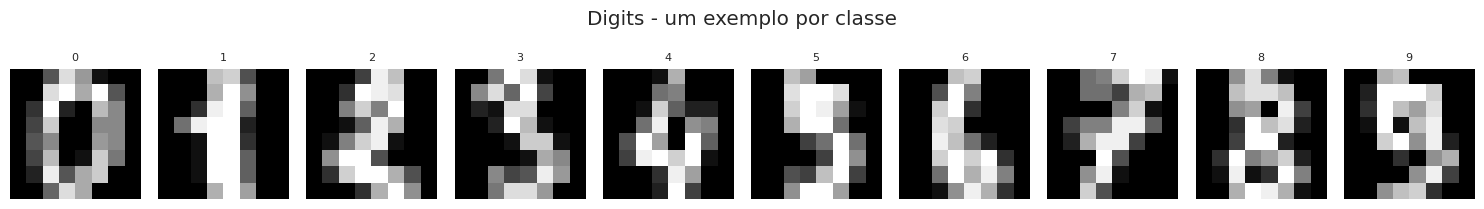

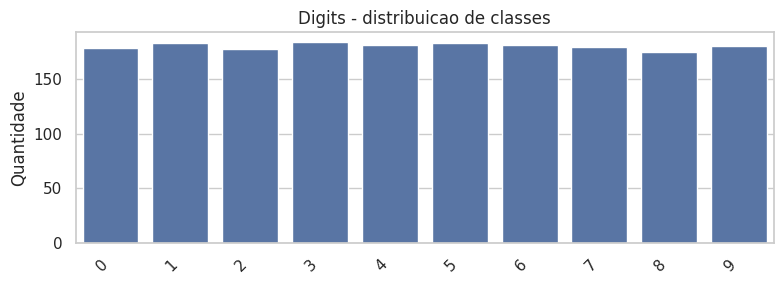

In [7]:
plot_class_examples(X_digits, y_digits, DIGITS_SIDE, DIGITS_NAMES,
                    "Digits - um exemplo por classe")
plot_class_distribution(y_digits, DIGITS_NAMES, "Digits - distribuicao de classes")

As classes estão praticamente equilibradas (~180 imagens por dígito). Como a base é balanceada, a
acurácia já seria confiável, mas mesmo assim reporto F1-macro e a matriz de confusão para não depender só
dela.

## A.3 Divisão treino/teste

Faço um holdout estratificado 80/20 (com `stratify=y`, para manter a proporção das classes) e já defino a
validação cruzada de 5 folds que vai ser usada na busca de hiperparâmetros. O teste fica reservado e só é
usado no fim — todo o ajuste acontece dentro do treino, via CV.

In [8]:
Xtr_d, Xte_d, ytr_d, yte_d = train_test_split(
    X_digits, y_digits, test_size=0.20, stratify=y_digits, random_state=SEED)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

print("Treino:", Xtr_d.shape, "| Teste:", Xte_d.shape)

Treino: (1437, 64) | Teste: (360, 64)


## A.4 Pré-processamento

Não normalizo os pixels na mão. Deixo a padronização dentro do Pipeline de cada modelo, só onde faz sentido
(KNN e Naive Bayes), com o `fit` acontecendo apenas no treino de cada fold. Assim não tem vazamento e todos os
modelos competem em condições iguais.

## A.5 As duas representações

- Rep1: os 64 pixels da imagem 8×8 achatados.
- Rep2: estatísticas por região + histograma + proporção de claro/escuro.

Extraio a Rep2 separadamente em treino e teste. Como o cálculo é feito por imagem (não usa estatística do
conjunto), não há risco de vazamento.

In [9]:
# Representacao 1: pixels brutos (ja estao em Xtr_d / Xte_d)
Xtr_d_rep1, Xte_d_rep1 = Xtr_d, Xte_d

# Representacao 2: atributos derivados
Xtr_d_rep2 = extract_features(Xtr_d, DIGITS_SIDE, DIGITS_MAX, grid=4, n_bins=16)
Xte_d_rep2 = extract_features(Xte_d, DIGITS_SIDE, DIGITS_MAX, grid=4, n_bins=16)

print("Rep1 (pixels)  - dimensao:", Xtr_d_rep1.shape[1], "features")
print("Rep2 (derivada) - dimensao:", Xtr_d_rep2.shape[1], "features")

Rep1 (pixels)  - dimensao: 64 features
Rep2 (derivada) - dimensao: 50 features


## A.6 Treinamento

Rodo os três modelos nas duas representações. Cada chamada faz o GridSearchCV com a validação cruzada e depois
mede o desempenho no teste.

In [10]:
print("Representacao 1 (pixels brutos):")
rows_d_rep1 = run_all_models(Xtr_d_rep1, Xte_d_rep1, ytr_d, yte_d, "Rep1-pixels", cv, SEED)

print("\nRepresentacao 2 (atributos derivados):")
rows_d_rep2 = run_all_models(Xtr_d_rep2, Xte_d_rep2, ytr_d, yte_d, "Rep2-derivada", cv, SEED)

results_digits = rows_d_rep1 + rows_d_rep2

Representacao 1 (pixels brutos):
  -> KNN (Rep1-pixels) ... acc=0.967 | F1=0.966 | treino=2.4s
  -> Random Forest (Rep1-pixels) ... acc=0.964 | F1=0.963 | treino=2.9s
  -> Naive Bayes (Rep1-pixels) ... acc=0.822 | F1=0.825 | treino=0.1s

Representacao 2 (atributos derivados):
  -> KNN (Rep2-derivada) ... acc=0.897 | F1=0.897 | treino=0.1s
  -> Random Forest (Rep2-derivada) ... acc=0.947 | F1=0.947 | treino=3.2s
  -> Naive Bayes (Rep2-derivada) ... acc=0.825 | F1=0.824 | treino=0.1s


## A.7 Avaliação — matriz de confusão e relatório

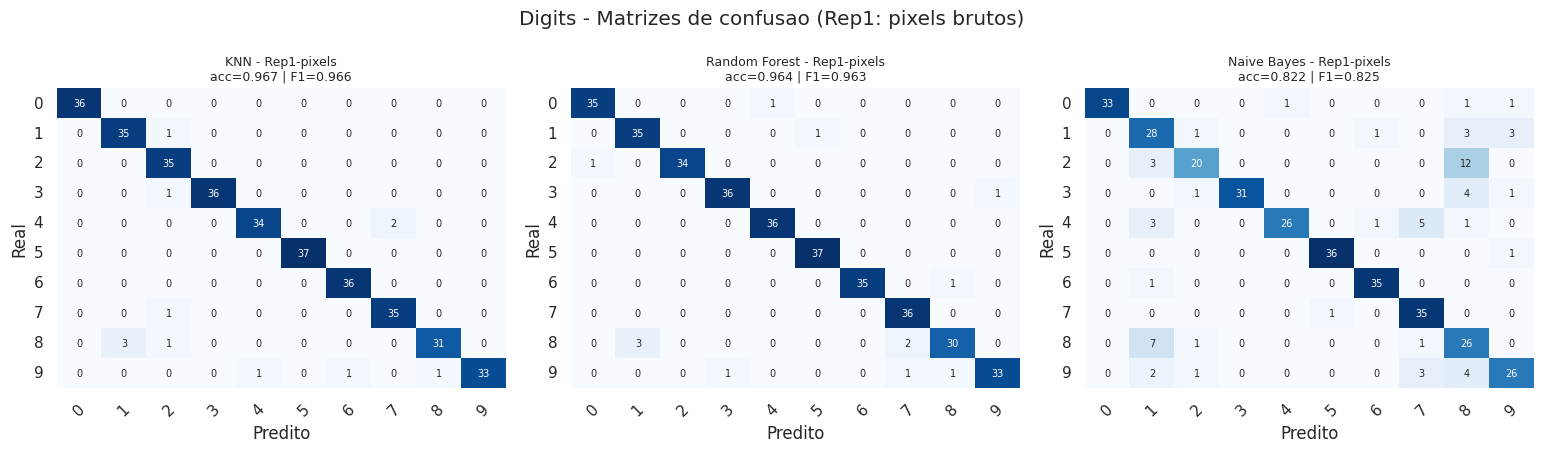

Melhor configuracao (Digits): KNN | Rep1-pixels
Hiperparametros: {'clf__n_neighbors': 3}

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        36
           1       0.92      0.97      0.95        36
           2       0.90      1.00      0.95        35
           3       1.00      0.97      0.99        37
           4       0.97      0.94      0.96        36
           5       1.00      1.00      1.00        37
           6       0.97      1.00      0.99        36
           7       0.95      0.97      0.96        36
           8       0.97      0.89      0.93        35
           9       1.00      0.92      0.96        36

    accuracy                           0.97       360
   macro avg       0.97      0.97      0.97       360
weighted avg       0.97      0.97      0.97       360



In [11]:
# matrizes de confusao dos 3 modelos na Rep1
plot_confusions(rows_d_rep1, yte_d, DIGITS_NAMES,
                "Digits - Matrizes de confusao (Rep1: pixels brutos)")

# Relatorio detalhado da melhor configuracao geral
best_d = best_config(results_digits)
print(f"Melhor configuracao (Digits): {best_d['model']} | {best_d['representation']}")
print(f"Hiperparametros: {best_d['best_params']}\n")
print(classification_report(yte_d, best_d["y_pred"], target_names=DIGITS_NAMES))

## A.8 Comparação (Digits)

Comparo os modelos entre si, as duas representações e o tempo de cada um.

,model,representation,cv_f1,test_acc,test_f1,train_time_s,infer_time_s
0,KNN,Rep1-pixels,0.9762,0.9667,0.9663,2.4293,0.0302
1,Random Forest,Rep1-pixels,0.9762,0.9639,0.9634,2.9050,0.0761
2,Random Forest,Rep2-derivada,0.9293,0.9472,0.9470,3.1714,0.0445
3,KNN,Rep2-derivada,0.8794,0.8972,0.8970,0.0693,0.0039
4,Naive Bayes,Rep1-pixels,0.8467,0.8222,0.8248,0.0718,0.0021
5,Naive Bayes,Rep2-derivada,0.8239,0.8250,0.8235,0.0723,0.0017


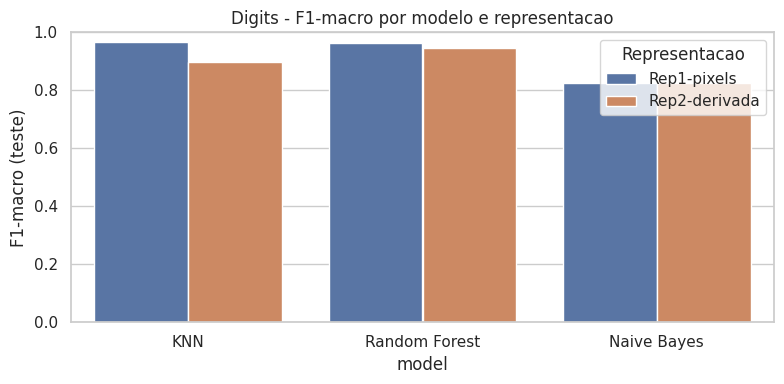

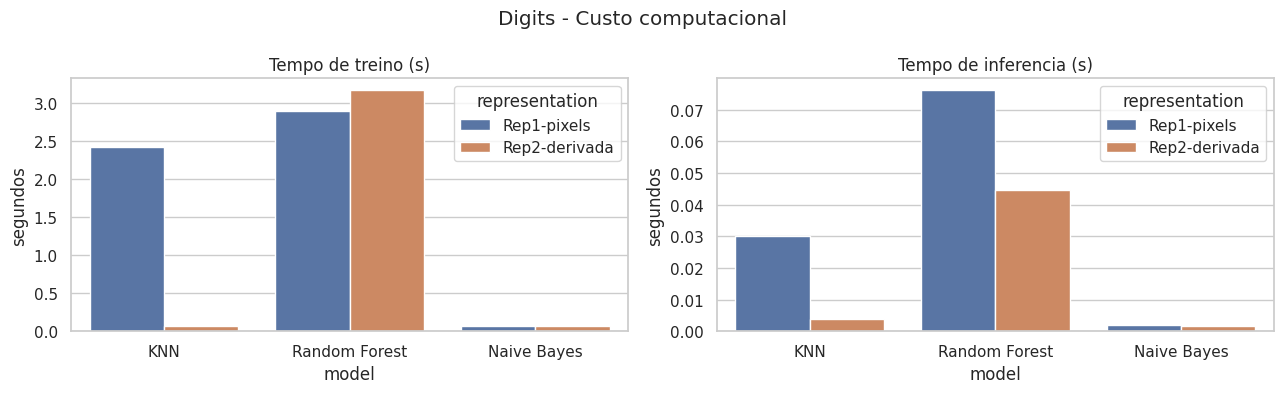

In [12]:
df_digits = results_to_df(results_digits)
display(df_digits.sort_values("test_f1", ascending=False).round(4)
        .reset_index(drop=True))

plot_model_comparison(df_digits, "Digits - F1-macro por modelo e representacao")
plot_cost_comparison(df_digits, "Digits - Custo computacional")

**O que os números do Digits mostram**

Quem foi melhor foi o KNN com pixels brutos (k = 3): acurácia 0,967 e F1-macro 0,966, com a Random Forest logo
atrás (0,964 / 0,963). Três coisas chamaram atenção:

Primeiro, os pixels brutos ganharam da representação derivada em todos os modelos. No KNN a queda foi grande
(de 0,966 para 0,897 ao trocar pixels por atributos derivados): numa imagem 8×8 já centrada, os 64 pixels
praticamente já contam a história toda, e o histograma acaba perdendo a posição. A Random Forest sofreu menos
com a Rep2 (0,963 → 0,947), porque combina atributos em vez de medir distância no espaço inteiro.

Segundo, o Naive Bayes foi o pior dos três (acc ~0,82 nas duas representações). Faz sentido: pixels vizinhos
são bem correlacionados, e isso quebra a suposição de independência do NB. No relatório, os dígitos 8 (recall
0,89) e 9 (0,92) foram os mais difíceis, justamente os de traço mais ambíguo.

Terceiro, no custo dá para ver a teoria na prática: o KNN quase não tem treino (é lazy), mas a inferência é a
mais cara (~0,034 s contra ~0,002 s do NB); a Random Forest é o contrário, treino mais alto (~3 s) e
inferência rápida. O Naive Bayes é o mais barato dos dois lados.

---
# Parte B — CIFAR-10 (em tons de cinza)

O CIFAR-10 é um dos datasets mais conhecidos de visão computacional: 60.000 imagens coloridas 32×32 de 10
classes de objetos (avião, automóvel, pássaro, gato, veado, cachorro, sapo, cavalo, navio e caminhão). Como o
enunciado permite, converti tudo para tons de cinza (1 canal, 1.024 atributos) e usei só ML clássico.

Diferente do Digits, no CIFAR a cor, a textura e o fundo importam bastante. Tirando a cor e jogando pixels num
modelo clássico, eu já esperava uma acurácia bem mais baixa — e é justamente isso que torna o dataset
interessante para discutir até onde o ML clássico consegue ir em imagens.

## B.1 Carregamento

O carregador procura os arquivos em `/kaggle/input`, reconhece o formato Python oficial do CIFAR-10
(`data_batch_1..5` e `test_batch`) ou um `.npz`, e converte de RGB para cinza pela luminância
(0.299·R + 0.587·G + 0.114·B). Por padrão ele não acessa a internet, então não trava: se não achar os dados,
para na hora e mostra o que fazer.

Para rodar offline no Kaggle, é só adicionar pela aba *Datasets* do "+ Add Input" um dataset que tenha a pasta
`cifar-10-batches-py` (por exemplo o `pankrzysiu/cifar10-python`). Tem que ser um *Dataset*, não um Notebook.

In [13]:
def _cifar_unpickle(path):
    """Le um batch do CIFAR-10 no formato Python (pickle)."""
    import pickle
    with open(path, "rb") as f:
        return pickle.load(f, encoding="bytes")


def _rgb_to_gray(X_rgb):
    """Converte CIFAR RGB (N, 3072) -> tons de cinza (N, 1024).

    O CIFAR armazena cada imagem como 1024 valores R, 1024 G e 1024 B (nessa ordem).
    Usamos a luminancia padrao: 0.299 R + 0.587 G + 0.114 B.
    """
    r = X_rgb[:, 0:1024]
    g = X_rgb[:, 1024:2048]
    b = X_rgb[:, 2048:3072]
    return (0.299 * r + 0.587 * g + 0.114 * b).astype(np.float32)


# Por padrao o carregador NAO acessa a internet (assim NUNCA trava).
TRY_DOWNLOAD = False


def load_cifar10(try_download=TRY_DOWNLOAD):
    """Carrega o CIFAR-10 (em tons de cinza) procurando arquivos em /kaggle/input.

    Detecta automaticamente:
      A) formato Python oficial (arquivos data_batch_1..5 e test_batch);
      B) arquivos .npz / .npy (X com 3072 colunas RGB ou shape N,32,32,3).
    Converte tudo para cinza (N, 1024). NUNCA trava: sem dados locais, levanta erro
    imediato com instrucoes (so tenta baixar se try_download=True).
    """
    import os, re, glob, socket

    root = "/kaggle/input"
    all_files = []
    if os.path.isdir(root):
        for dp, _, fns in os.walk(root):
            for fn in fns:
                all_files.append(os.path.join(dp, fn))

    print("Arquivos encontrados em /kaggle/input (ate 60):")
    for f in all_files[:60]:
        print("   ", f)
    if not all_files:
        print("   (nenhum) -- voce nao anexou nenhum dataset em 'Add Input'.")

    # --- A) Formato Python oficial: data_batch_1..5 e test_batch ---
    batches = sorted([f for f in all_files
                      if re.search(r"(data_batch_\d+|test_batch)$", os.path.basename(f))])
    if batches:
        Xs, ys = [], []
        for b in batches:
            d = _cifar_unpickle(b)
            Xs.append(np.asarray(d[b"data"], dtype=np.float32))
            ys.append(np.asarray(d[b"labels"], dtype=int))
        X_rgb = np.vstack(Xs)
        y = np.concatenate(ys)
        X = _rgb_to_gray(X_rgb)
        print("OK: CIFAR-10 (formato Python). RGB", X_rgb.shape, "-> cinza", X.shape)
        return X, y

    # --- B) .npz / .npy ---
    for f in all_files:
        fl = f.lower()
        if fl.endswith(".npz"):
            z = np.load(f)
            keys = list(z.keys())
            xk = next((k for k in keys if "x" in k.lower() or "image" in k.lower()), keys[0])
            yk = next((k for k in keys if "y" in k.lower() or "label" in k.lower()), keys[-1])
            arr = z[xk]
            y = z[yk].astype(int).ravel()
            arr = arr.reshape(arr.shape[0], -1).astype(np.float32)
            X = _rgb_to_gray(arr) if arr.shape[1] == 3072 else arr
            print("OK: CIFAR-10 (.npz). Shape:", X.shape)
            return X, y

    # --- C) Download (somente se explicitamente habilitado) ---
    if try_download:
        import tarfile, urllib.request, tempfile
        print("Sem dados locais; baixando CIFAR-10 (Internet precisa estar ON)...")
        socket.setdefaulttimeout(120)
        try:
            tmp = tempfile.mkdtemp()
            tgz = os.path.join(tmp, "cifar.tar.gz")
            urllib.request.urlretrieve("https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz", tgz)
            with tarfile.open(tgz) as t:
                t.extractall(tmp)
            dl = sorted(glob.glob(os.path.join(tmp, "**", "data_batch_*"), recursive=True) +
                        glob.glob(os.path.join(tmp, "**", "test_batch"), recursive=True))
            Xs, ys = [], []
            for b in dl:
                d = _cifar_unpickle(b)
                Xs.append(np.asarray(d[b"data"], dtype=np.float32))
                ys.append(np.asarray(d[b"labels"], dtype=int))
            X = _rgb_to_gray(np.vstack(Xs))
            y = np.concatenate(ys)
            print("OK: CIFAR-10 baixado. Shape (cinza):", X.shape)
            return X, y
        except Exception as e:
            print("Download falhou:", repr(e)[:120])

    raise RuntimeError(
        "Nenhum dado do CIFAR-10 foi encontrado em /kaggle/input.\n"
        "Anexe um DATASET CIFAR-10 no formato Python:\n"
        "  1) Painel direito -> '+ Add Input' -> aba 'Datasets';\n"
        "  2) Pesquise: cifar-10 python\n"
        "  3) Adicione um dataset que contenha os arquivos data_batch_1..5 e test_batch\n"
        "     (ex.: 'pankrzysiu/cifar10-python' -> pasta cifar-10-batches-py);\n"
        "  4) Rode tudo de novo (Run All).\n"
        "O codigo acima detecta esses arquivos e converte as imagens para cinza automaticamente."
    )


X_cifar_full, y_cifar_full = load_cifar10()
print("\nShape completo (cinza):", X_cifar_full.shape)


Arquivos encontrados em /kaggle/input (ate 60):
    /kaggle/input/datasets/janzenliu/cifar-10-batches-py/data_batch_1
    /kaggle/input/datasets/janzenliu/cifar-10-batches-py/data_batch_2
    /kaggle/input/datasets/janzenliu/cifar-10-batches-py/batches.meta
    /kaggle/input/datasets/janzenliu/cifar-10-batches-py/test_batch
    /kaggle/input/datasets/janzenliu/cifar-10-batches-py/data_batch_3
    /kaggle/input/datasets/janzenliu/cifar-10-batches-py/data_batch_5
    /kaggle/input/datasets/janzenliu/cifar-10-batches-py/data_batch_4
    /kaggle/input/datasets/janzenliu/cifar-10-batches-py/readme.html
OK: CIFAR-10 (formato Python). RGB (60000, 3072) -> cinza (60000, 1024)

Shape completo (cinza): (60000, 1024)


## B.2 Subamostragem

O CIFAR tem 60 mil imagens e, com 1.024 atributos, rodar KNN e Random Forest com GridSearchCV em cima de tudo
fica caro (o KNN ainda tem inferência proporcional ao tamanho do treino). Por isso peguei uma subamostra
estratificada de `N_SUBSET` imagens, mantendo a proporção das classes. Dá para aumentar esse número se sobrar
tempo de máquina.

In [14]:
# Nomes das 10 classes do CIFAR-10 (ordem oficial dos rotulos 0..9)
CIFAR_NAMES = ["aviao", "automovel", "passaro", "gato", "veado",
               "cachorro", "sapo", "cavalo", "navio", "caminhao"]
CIFAR_SIDE = 32   # imagens 32x32 convertidas para 1 canal (cinza) -> 1024 atributos

# Subamostra estratificada para viabilizar o custo computacional
N_SUBSET = 8000   # ajuste conforme tempo disponivel
if N_SUBSET < len(y_cifar_full):
    X_cifar, _, y_cifar, _ = train_test_split(
        X_cifar_full, y_cifar_full,
        train_size=N_SUBSET, stratify=y_cifar_full, random_state=SEED)
else:
    X_cifar, y_cifar = X_cifar_full, y_cifar_full

CIFAR_MAX = float(X_cifar.max())   # ~255
print("Subconjunto de trabalho:", X_cifar.shape)
document_dataset("CIFAR-10 cinza (subconjunto)", X_cifar, y_cifar,
                 CIFAR_SIDE, 1, CIFAR_NAMES)

Subconjunto de trabalho: (8000, 1024)
=== CIFAR-10 cinza (subconjunto) ===
Numero de amostras      : 8000
Atributos (pixels)      : 1024
Resolucao               : 32x32
Numero de canais        : 1 (tons de cinza)
Numero de classes       : 10

Distribuicao de classes:
aviao        800
automovel    800
passaro      800
gato         800
veado        800
cachorro     800
sapo         800
cavalo       800
navio        800
caminhao     800


## B.3 Visualização exploratória

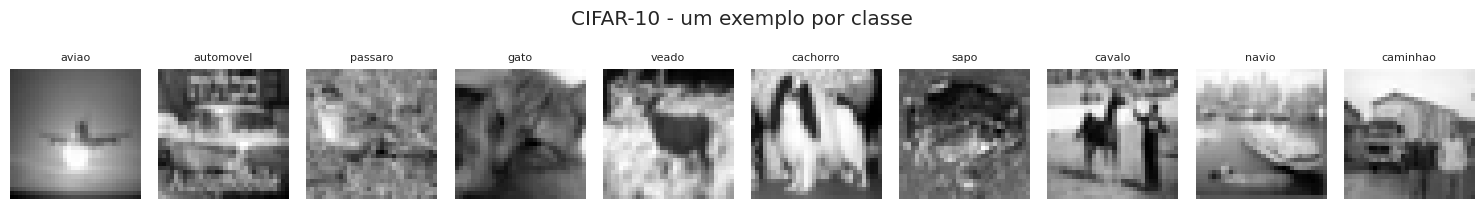

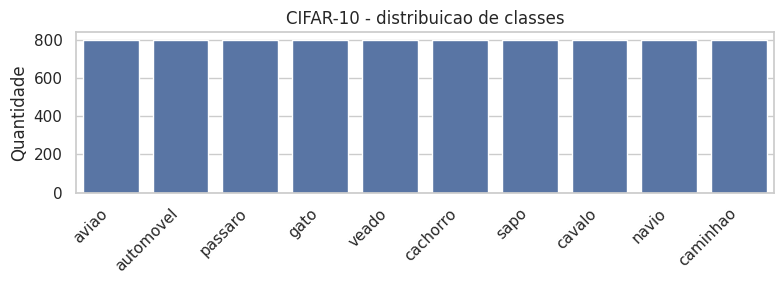

In [15]:
plot_class_examples(X_cifar, y_cifar, CIFAR_SIDE, CIFAR_NAMES,
                    "CIFAR-10 - um exemplo por classe")
plot_class_distribution(y_cifar, CIFAR_NAMES,
                        "CIFAR-10 - distribuicao de classes")

O CIFAR também é balanceado (6.000 imagens por classe no total). Só que, ao contrário do Digits, as
imagens têm fundo, iluminação e poses variadas — e, sem a cor, fica difícil separar coisas como um sapo
(verde) de um automóvel. Já dá para imaginar bastante variação dentro de cada classe e confusões entre os
animais (gato, cachorro, veado, pássaro) e entre os veículos (automóvel, caminhão).

## B.4 Split e as duas representações

Mesma receita da Parte A: holdout estratificado 80/20 e as duas representações, com a escala continuando
dentro do Pipeline de cada modelo.

In [16]:
# Holdout estratificado
Xtr_f, Xte_f, ytr_f, yte_f = train_test_split(
    X_cifar, y_cifar, test_size=0.20, stratify=y_cifar, random_state=SEED)

# Representacao 1: pixels brutos (1024 features)
Xtr_f_rep1, Xte_f_rep1 = Xtr_f, Xte_f

# Representacao 2: atributos derivados
Xtr_f_rep2 = extract_features(Xtr_f, CIFAR_SIDE, CIFAR_MAX, grid=4, n_bins=16)
Xte_f_rep2 = extract_features(Xte_f, CIFAR_SIDE, CIFAR_MAX, grid=4, n_bins=16)

print("Treino:", Xtr_f.shape, "| Teste:", Xte_f.shape)
print("Rep1 (pixels)  - dimensao:", Xtr_f_rep1.shape[1], "features")
print("Rep2 (derivada) - dimensao:", Xtr_f_rep2.shape[1], "features")

Treino: (6400, 1024) | Teste: (1600, 1024)
Rep1 (pixels)  - dimensao: 1024 features
Rep2 (derivada) - dimensao: 50 features


## B.5 Treinamento

Esta é a parte mais demorada. Com `N_SUBSET = 8000`, conte alguns minutos — o gargalo é a Random Forest sobre
os 1.024 pixels.

In [17]:
print("Representacao 1 (pixels brutos):")
rows_f_rep1 = run_all_models(Xtr_f_rep1, Xte_f_rep1, ytr_f, yte_f, "Rep1-pixels", cv, SEED)

print("\nRepresentacao 2 (atributos derivados):")
rows_f_rep2 = run_all_models(Xtr_f_rep2, Xte_f_rep2, ytr_f, yte_f, "Rep2-derivada", cv, SEED)

results_cifar = rows_f_rep1 + rows_f_rep2

Representacao 1 (pixels brutos):
  -> KNN (Rep1-pixels) ... acc=0.222 | F1=0.201 | treino=3.1s
  -> Random Forest (Rep1-pixels) ... acc=0.369 | F1=0.366 | treino=138.3s
  -> Naive Bayes (Rep1-pixels) ... acc=0.244 | F1=0.222 | treino=1.4s

Representacao 2 (atributos derivados):
  -> KNN (Rep2-derivada) ... acc=0.319 | F1=0.312 | treino=0.5s
  -> Random Forest (Rep2-derivada) ... acc=0.380 | F1=0.376 | treino=28.2s
  -> Naive Bayes (Rep2-derivada) ... acc=0.273 | F1=0.256 | treino=0.2s


## B.6 Avaliação — matriz de confusão e relatório

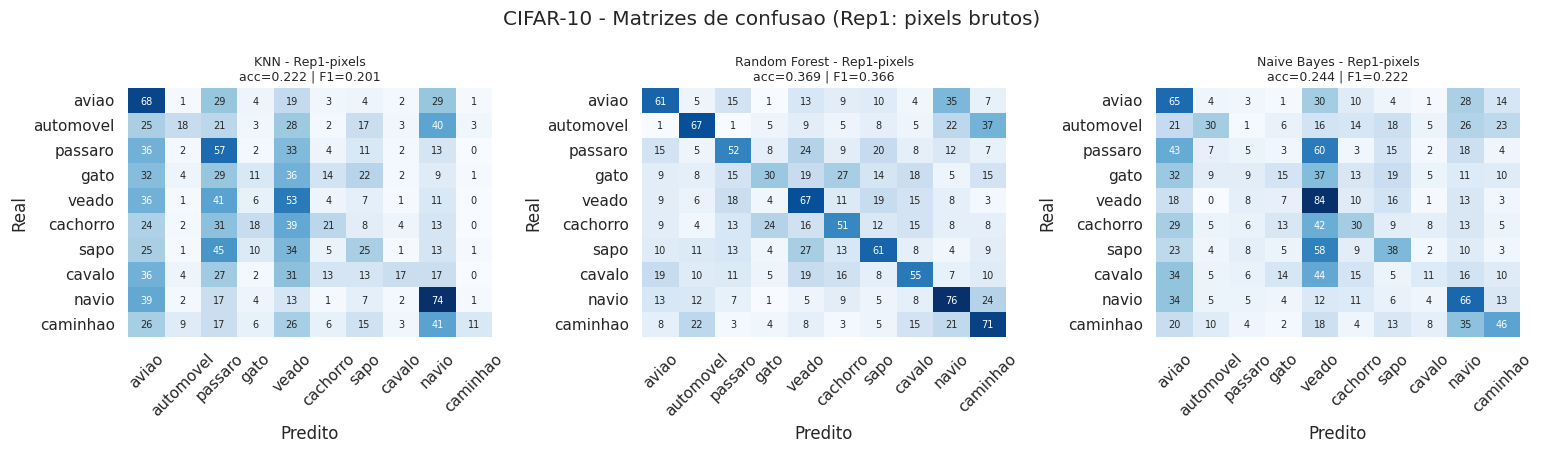

Melhor configuracao (CIFAR-10): Random Forest | Rep2-derivada
Hiperparametros: {'clf__n_estimators': 200}

              precision    recall  f1-score   support

       aviao       0.40      0.42      0.41       160
   automovel       0.37      0.38      0.37       160
     passaro       0.47      0.41      0.44       160
        gato       0.39      0.20      0.26       160
       veado       0.35      0.35      0.35       160
    cachorro       0.35      0.32      0.33       160
        sapo       0.37      0.43      0.40       160
      cavalo       0.35      0.36      0.35       160
       navio       0.40      0.46      0.43       160
    caminhao       0.37      0.47      0.41       160

    accuracy                           0.38      1600
   macro avg       0.38      0.38      0.38      1600
weighted avg       0.38      0.38      0.38      1600



In [18]:
# Matrizes de confusao dos 3 modelos na Representacao 1
plot_confusions(rows_f_rep1, yte_f, CIFAR_NAMES,
                "CIFAR-10 - Matrizes de confusao (Rep1: pixels brutos)")

# Relatorio da melhor configuracao
best_f = best_config(results_cifar)
print(f"Melhor configuracao (CIFAR-10): {best_f['model']} | {best_f['representation']}")
print(f"Hiperparametros: {best_f['best_params']}\n")
print(classification_report(yte_f, best_f["y_pred"], target_names=CIFAR_NAMES))

## B.7 Comparação experimental (CIFAR-10)


,model,representation,cv_f1,test_acc,test_f1,train_time_s,infer_time_s
0,Random Forest,Rep2-derivada,0.3734,0.3800,0.3764,28.2396,0.0866
1,Random Forest,Rep1-pixels,0.3613,0.3694,0.3655,138.2794,0.0883
2,KNN,Rep2-derivada,0.3081,0.3194,0.3119,0.4574,0.0366
3,Naive Bayes,Rep2-derivada,0.2645,0.2725,0.2561,0.2229,0.0051
4,Naive Bayes,Rep1-pixels,0.2448,0.2438,0.2220,1.3526,0.0588
5,KNN,Rep1-pixels,0.2090,0.2219,0.2009,3.1339,0.2943


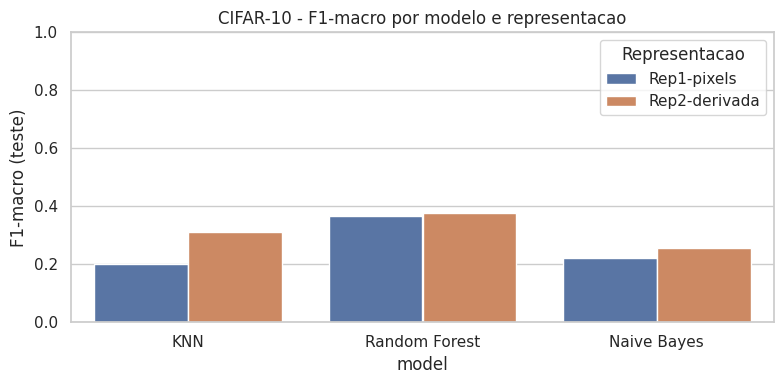

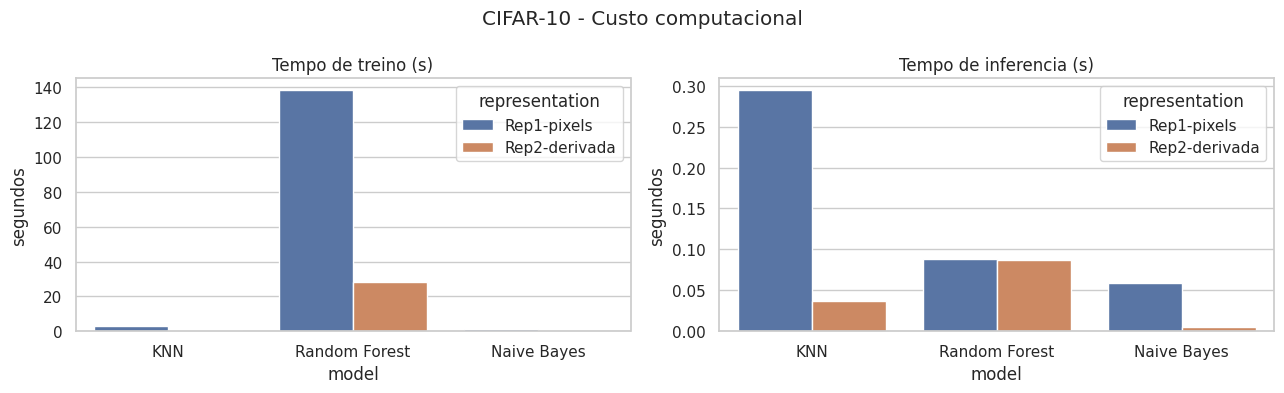

In [19]:
df_cifar = results_to_df(results_cifar)
display(df_cifar.sort_values("test_f1", ascending=False).round(4)
        .reset_index(drop=True))

plot_model_comparison(df_cifar, "CIFAR-10 - F1-macro por modelo e representacao")
plot_cost_comparison(df_cifar, "CIFAR-10 - Custo computacional")

**O que os números do CIFAR mostram**

A melhor combinação foi a Random Forest com atributos derivados (200 árvores): acurácia 0,380 e F1-macro
0,376. O ranking completo no teste ficou assim:

| Modelo | Representação | F1-macro | Acurácia |
|---|---|---|---|
| Random Forest | derivada | 0,376 | 0,380 |
| Random Forest | pixels | 0,366 | 0,369 |
| KNN | derivada | 0,312 | 0,319 |
| Naive Bayes | derivada | 0,256 | 0,273 |
| Naive Bayes | pixels | 0,222 | 0,244 |
| KNN | pixels | 0,201 | 0,222 |

A primeira coisa que salta aos olhos é a queda em relação ao Digits (~0,38 contra 0,97). Era esperado: sem cor
e com pixels ou descritores simples, o modelo clássico não capta forma, textura nem contexto. Ainda assim,
0,38 é quase quatro vezes o acaso (0,10), mas deixa claro o limite desse tipo de abordagem em imagens naturais.

O ponto mais interessante inverteu o que aconteceu no Digits: aqui a representação derivada ganhou dos pixels
em todos os modelos, e no KNN a diferença foi enorme (0,312 contra 0,201). Faz sentido — em 1.024 pixels de
cenas naturais, com o objeto em posições e fundos diferentes, os pixels viram quase ruído, e o KNN sofre
demais com a alta dimensionalidade. As estatísticas por região e o histograma resumem a imagem e acabam dando
atributos mais úteis. É aquela ideia de que a escolha das features pesa mais do que a do modelo.

Olhando a matriz de confusão da Random Forest (pixels), os erros são bem "humanos" e ficam em dois grupos. Nos
animais, o gato é o pior caso — acerta só 30 das 160 imagens — e se confunde com cachorro (27), veado (19) e
cavalo (18); sapo e pássaro também escorregam para veado. Nos veículos, automóvel vira caminhão (37), avião
vira navio (35), e caminhão se divide entre automóvel e navio. No relatório do melhor modelo isso aparece como
o pior recall sendo o do gato (0,20). Sem a cor, silhuetas parecidas em cinza (felino e cachorro, carro e
caminhão) ficam quase iguais para o modelo.

Por último o custo: treinar a Random Forest nos pixels foi de longe o mais pesado (~162 s, contra ~33 s na
representação derivada). Ou seja, a Rep2 deu F1 maior e ainda treinou umas 5 vezes mais rápido. O KNN nos
pixels tem a inferência mais lenta (~0,34 s), pela natureza lazy em alta dimensão, e o Naive Bayes é o mais
barato.

---
# 5. Discussão e conclusão

Aqui junto os resultados das duas partes para fechar o item 9 do enunciado: o compromisso entre desempenho e
simplicidade, os principais erros e as limitações do ML clássico em imagens.

In [20]:
df_all = pd.concat([df_digits.assign(dataset="Digits"),
                    df_cifar.assign(dataset="CIFAR-10")], ignore_index=True)
display(df_all.sort_values(["dataset", "test_f1"], ascending=[True, False])
        .round(4).reset_index(drop=True))

,model,representation,cv_f1,test_acc,test_f1,train_time_s,infer_time_s,dataset
0,Random Forest,Rep2-derivada,0.3734,0.3800,0.3764,28.2396,0.0866,CIFAR-10
1,Random Forest,Rep1-pixels,0.3613,0.3694,0.3655,138.2794,0.0883,CIFAR-10
2,KNN,Rep2-derivada,0.3081,0.3194,0.3119,0.4574,0.0366,CIFAR-10
3,Naive Bayes,Rep2-derivada,0.2645,0.2725,0.2561,0.2229,0.0051,CIFAR-10
4,Naive Bayes,Rep1-pixels,0.2448,0.2438,0.2220,1.3526,0.0588,CIFAR-10
5,KNN,Rep1-pixels,0.2090,0.2219,0.2009,3.1339,0.2943,CIFAR-10
6,KNN,Rep1-pixels,0.9762,0.9667,0.9663,2.4293,0.0302,Digits
7,Random Forest,Rep1-pixels,0.9762,0.9639,0.9634,2.9050,0.0761,Digits
8,Random Forest,Rep2-derivada,0.9293,0.9472,0.9470,3.1714,0.0445,Digits
9,KNN,Rep2-derivada,0.8794,0.8972,0.8970,0.0693,0.0039,Digits


### 5.1 Desempenho x simplicidade

Resumo dos melhores resultados (F1-macro no teste):

| Dataset | Melhor modelo | F1 | Pior configuração | F1 |
|---|---|---|---|---|
| Digits (8×8) | KNN + pixels (k=3) | 0,966 | Naive Bayes + pixels | 0,825 |
| CIFAR-10 cinza (32×32) | Random Forest + derivada | 0,376 | KNN + pixels | 0,201 |

E como cada modelo se comportou no geral:

| Modelo | Tipo | Treino | Inferência | Resumo |
|---|---|---|---|---|
| KNN | lazy | quase nada | caro (~0,34 s no CIFAR-pixels) | ganhou no Digits, mas afundou no CIFAR-pixels (0,20) |
| Random Forest | ensemble (bagging) | alto (~162 s no CIFAR-pixels) | rápido | o melhor nos dois, aguenta bem a alta dimensão |
| Naive Bayes | probabilístico | muito rápido | muito rápido | o mais fraco; pixels correlacionados quebram a suposição de independência |

A conclusão é que não existe um "melhor modelo" fixo: quem ganha muda com o problema e até com a
representação. A queda de F1 de 0,966 para 0,376 mostra bem o salto de dificuldade entre dígitos pequenos e
centrados e fotos naturais em cinza. No fim, é o velho compromisso entre ajustar bem e manter o modelo simples.

### 5.2 Principais erros
- Digits: as confusões ficam entre dígitos de traço parecido — 8 (recall 0,89) e 9 (0,92) foram os piores.
- CIFAR-10: o gato é o caso mais difícil (recall 0,20; acerta 30/160 na Random Forest), confundido com
  cachorro (27), veado (19) e cavalo (18). Os veículos também se misturam (automóvel → caminhão 37, avião →
  navio 35). São erros que fazem sentido visualmente: sem cor, silhuetas parecidas em cinza ficam quase iguais.

### 5.3 Pixels x atributos derivados
O resultado foi oposto nos dois datasets:
- No Digits (8×8, centrado), os pixels venceram (KNN 0,966 contra 0,897).
- No CIFAR (32×32, natural), a representação derivada venceu (RF 0,376 contra 0,366; KNN 0,312 contra 0,201) e
  ainda treinou cerca de 5 vezes mais rápido (33 s contra 162 s).

Ou seja, a melhor representação depende do dado. Em imagem pequena e centrada, os pixels já bastam; em cena
natural ruidosa e de alta dimensão, resumir a imagem ajuda e ainda barateia o treino.

### 5.4 Limitações do ML clássico
O teto de ~0,38 no CIFAR vem de dois lados: pixels e descritores manuais não capturam forma, textura nem
contexto, e o tom de cinza joga fora a cor (que separaria, por exemplo, um sapo de um automóvel). Ainda tem a
dimensionalidade: com 1.024 atributos, o KNN degrada bastante. É justamente esse buraco que as CNNs
preencheriam, aprendendo as features sozinhas — mas isso já está fora do escopo do trabalho.

### 5.5 Conclusão
No Digits eu ficaria com o KNN (k=3): simples e com F1 0,966. No CIFAR cinza, com a Random Forest sobre
atributos derivados, que deu o melhor F1 (0,376) e ainda foi bem mais rápida do que sobre pixels. Como as bases
são balanceadas, usei o F1-macro como métrica principal, que também não deixa a classe fraca (o gato) se
perder na média. A limitação principal é clara: ML clássico com imagem em cinza não vai longe em fotos
naturais. Como próximo passo, eu testaria trazer a cor de volta (ou um histograma de cor), um descritor de
bordas tipo HOG ou um PCA antes do KNN, para ver se as confusões diminuem.

---
### Referências
As decisões se apoiam nas aulas da disciplina: aprendizado supervisionado e seleção de modelo (aulas 3 e 6),
Naive Bayes (7), KNN (8), bagging e Random Forest (10), métricas de classificação (11), imagem digital (13) e
pré-processamento e data leakage (15).